In [1]:
import numpy as np
import matplotlib.pyplot as plt


from snudd.geometry import SolarAngles

In [2]:
t0 = 91
T  = 182*2

GranSasso = SolarAngles(latitude=42.47, t0=t0, T=T)

In [8]:
angles, weights = GranSasso.zenith_hist(bins=25)
# print(angles, weights)

In [4]:
from snudd.nsi import earth_matter as em 
from snudd.nsi import oscillation as osc 
from snudd.models import GeneralNSI
import snudd.nsi.nsi_probabilities as probs

In [5]:
SM_matrix = np.array([[0, 0, 0],
                      [0, 0, 0],
                      [0, 0, 0]])

eta = 0
phi = 0

sm_model = GeneralNSI(SM_matrix, eta, phi)



Enuspace = np.geomspace(1e-6,2e1, 400)


xr_km = [0., 1221.5, 3480.0, 5701.0, 5771.0, 5971.0, 6151.0,
               6346.6, 6356.0, 6368.0, 6371.0, 6371.0 + 15.0]  # your boundaries
coeffs = [
    (13.0885, 0.0, -8.8381, 0.0),   # layer 1: a,b,c,d in r = R/RE
    (12.5815, -1.2638, -3.6426, -5.528),  # layer 2
    (7.9565,  -6.4761,  5.5283,  -3.0807),  # ...
    (5.3197,  -1.4836,  0.0,  0.0),
    (11.2494,  -8.0298,  0.0,  0.0),
    (7.1089,  -3.8045,  0.0,  0.0),
    (2.6910,   0.6924,  0.0,  0.0),
    (2.9,      0.0,  0.0,  0.0),
    (2.6,    0.0,  0.0,  0.0),
    (1.02,    0.0,  0.0,  0.0),
    (0.000,    0.0,  0.0,  0.0),
]
PREMmodel = em.LayeredPolyEarth(xr_km=xr_km, coeffs=coeffs,
                         Ye_core=0.466, Ye_mantle=0.494)
PREMprob = em.EarthProbEvolve(osc_params=osc.osc_params_best, model=sm_model, earthmodel=PREMmodel, Nst=50, Nav=50 )



density_sm = probs.DensityMatrixCalculator(sm_model).density(Enuspace, '8B')



In [6]:
rho_earthceta1 = PREMprob.evolve_rhosolar(density_sm, Enuspace, ceta=0.025)

rho_earthceta2 = PREMprob.evolve_rhosolar(density_sm, Enuspace, ceta=0.5)

NameError: name 'rho_earth' is not defined

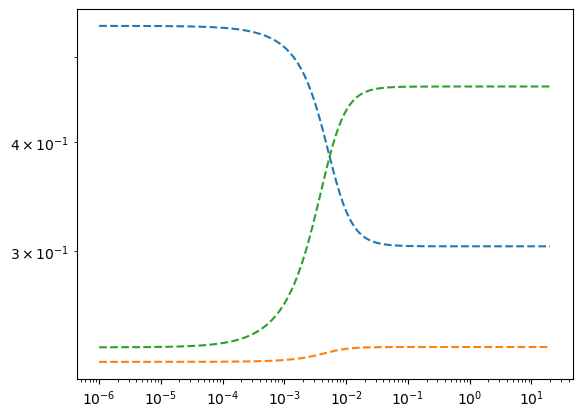

In [9]:
plt.loglog(Enuspace,abs(density_sm[:, 0,0]),  label=r'$\rho_{ee}$', 
            color="tab:blue", ls='--' )
plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$',
           color="tab:orange", ls='--' )

plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$',
           color="tab:green", ls='--' )

plt.loglog(Enuspace,abs(rho_earth[:, 0,0]),  color="tab:blue" )


plt.loglog(Enuspace,abs(rho_earth[:, 1,1]),  color="tab:orange" )


plt.loglog(Enuspace,abs(rho_earth[:, 2,2]),  color="tab:green" )
# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

#plt.loglog(Enuspace, Pee*, label=r'$P_{ee}$', ls=':', color="tab:blue" )


plt.xlim(xmin=1e-6, xmax=2.0e1)

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

In [10]:
np.shape(rho_earthceta1)

(400, 3, 3)

In [11]:
import tqdm as tqdm

In [12]:
weights.sum()

np.float64(1.0001401477372538)

In [14]:
def rho_weighted_average(probevolution, rhosm, Enuspace, weights, angles):


    rho_ave = np.zeros(np.shape(rhosm), dtype=complex)
    
    for i in tqdm.tqdm(range(len(weights))):
        ceta = np.cos(angles[i])
        # evolve through earth
        rho_earth = probevolution.evolve_rhosolar(rhosm, Enuspace, ceta=ceta)
        rho_ave += weights[i] * rho_earth

    return rho_ave
        

In [15]:
rho_ave = rho_weighted_average(PREMprob, density_sm, Enuspace, weights, angles)

100%|██████████| 50/50 [02:31<00:00,  3.03s/it]


Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

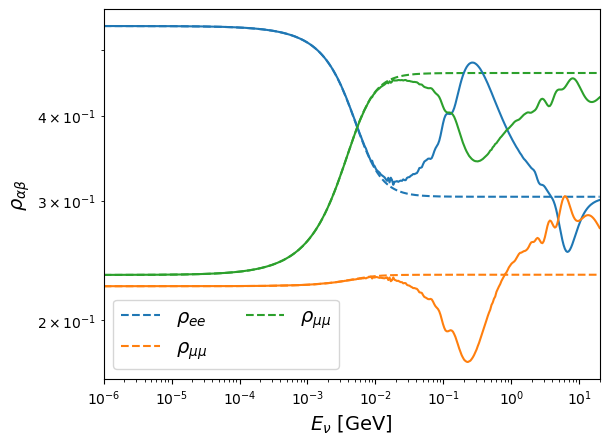

In [ ]:
plt.loglog(Enuspace,abs(density_sm[:, 0,0]),  label=r'$\rho_{ee}$', 
            color="tab:blue", ls='--' )
plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$',
           color="tab:orange", ls='--' )

plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$',
           color="tab:green", ls='--' )

plt.loglog(Enuspace,abs(rho_ave[:, 0,0]),  color="tab:blue" )


plt.loglog(Enuspace,abs(rho_ave[:, 1,1]),  color="tab:orange" )


plt.loglog(Enuspace,abs(rho_ave[:, 2,2]),  color="tab:green" )
# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

#plt.loglog(Enuspace, Pee*, label=r'$P_{ee}$', ls=':', color="tab:blue" )


plt.xlim(xmin=1e-6, xmax=2.0e1)

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

In [17]:
from snudd.nsi.oscillation import OscillationParameters

In [18]:
delta_m12 = 7.42e-5 *( 1e-9) ** 2 # GeV^2
delta_m31 = 2.517e-3 * (1e-9) ** 2  # GeV^2
theta_12 = np.arcsin(np.sqrt(0.304))
theta_13 = np.arcsin(np.sqrt(0.02219)) # NORMAL ORDERING
theta_23 = np.arcsin(np.sqrt(0.573))
delta_cp = 4.71238898038469  # CP angle

params1 = OscillationParameters(delta_m12, delta_m31,
                                        theta_12,
                                        theta_13,
                                        theta_23,
                                        delta_cp)

In [19]:
rho_sun2 = probs.DensityMatrixCalculator(sm_model, osc_params=params1).density(Enuspace, '8B')
PREMprob2 = em.EarthProbEvolve(osc_params=params1, model=sm_model, earthmodel=PREMmodel)



In [20]:
rho_ave2 = rho_weighted_average(PREMprob2, rho_sun2, Enuspace, weights, angles)

100%|██████████| 50/50 [02:45<00:00,  3.31s/it]


Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

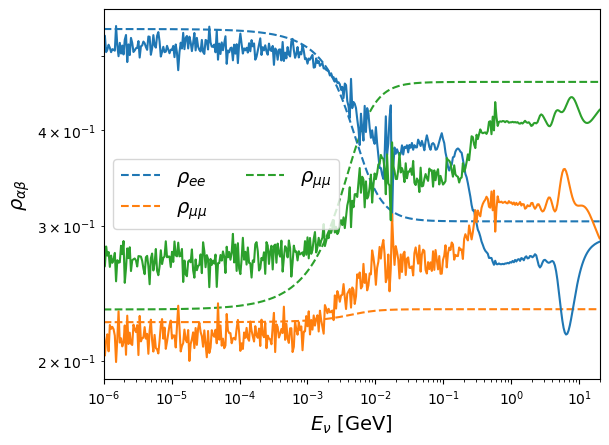

In [21]:
plt.loglog(Enuspace,abs(density_sm[:, 0,0]),  label=r'$\rho_{ee}$', 
            color="tab:blue", ls='--' )
plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$',
           color="tab:orange", ls='--' )

plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$',
           color="tab:green", ls='--' )

plt.loglog(Enuspace,abs(rho_ave2[:, 0,0]),  color="tab:blue" )


plt.loglog(Enuspace,abs(rho_ave2[:, 1,1]),  color="tab:orange" )


plt.loglog(Enuspace,abs(rho_ave2[:, 2,2]),  color="tab:green" )
# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

#plt.loglog(Enuspace, Pee*, label=r'$P_{ee}$', ls=':', color="tab:blue" )


plt.xlim(xmin=1e-6, xmax=2.0e1)

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

In [22]:
angles < np.pi/2

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False])